# Support Vector Machine — Complete Notebook (Classification + Regression)

This notebook is the **single source of truth** for SVM in this folder. It merges the original
Titanic SVC notebook (kept unchanged as a backup in `archive/Support_vector_Classifier_with_Scikit_Learn.ipynb`)
with brand-new material so that both halves of SVM — **SVC** (classification) and **SVR** (regression) —
are demonstrated end-to-end with real, runnable code.

Full theory (formulas, derivations, hand-worked numeric example, hyperparameter tables, pitfalls) lives in
`README.md` next to this notebook. This notebook focuses on **code + evaluation + plots**.

**Contents**

- **Part A — SVC**: Titanic survival prediction (preprocessing -> pipeline -> `GridSearchCV` -> full evaluation: accuracy/precision/recall/F1/confusion matrix/ROC-AUC + an illustrative 2D decision boundary)
- **Part B — Kernel Trick Demo**: linear vs polynomial vs RBF kernels on the same non-linear 2D dataset, decision boundaries side by side
- **Part C — Effect of `C` and `gamma`**: a small grid showing under-fitting vs over-fitting behaviour
- **Part D — SVR**: (1) a 1D toy example that visualizes the epsilon-insensitive "tube", and (2) a full real-dataset regression (`load_diabetes`) comparing linear vs RBF kernels with MSE/RMSE/MAE/R2


## Part A — Support Vector Classifier (SVC): Titanic Survival Prediction

This section reproduces and extends the original notebook's full workflow: data loading, feature
engineering, outlier handling, preprocessing pipelines, hyperparameter tuning with `GridSearchCV`,
and a complete evaluation (the original notebook only reported accuracy/precision/recall — here we
add F1, the confusion matrix, ROC-AUC, and a 2D decision-boundary visualization).


### A.0 Imports

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OrdinalEncoder, OneHotEncoder, LabelEncoder, StandardScaler, MinMaxScaler
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVC, SVR
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_auc_score, RocCurveDisplay,
    mean_squared_error, mean_absolute_error, r2_score
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


### A.1 Data Loading and Initial Exploration

We start by loading the raw Titanic data. EDA is crucial because it helps us identify missing values
and understand the data types (numerical vs. categorical) we need to handle later.

In [2]:
df = pd.read_csv("titanic_data_updated.csv")
df.sample(5, random_state=RANDOM_STATE)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
709,710,yes,third,"Moubarek, Master. Halim Gonios (""William George"")",male,NaN,1,1,2661,15.2458,NaN,C
439,440,no,second,"Kvillner, Mr. Johan Henrik Johannesson",male,31.0,0,0,C.A. 18723,10.5000,NaN,S
840,841,no,third,"Alhomaki, Mr. Ilmari Rudolf",male,20.0,0,0,SOTON/O2 3101287,7.9250,NaN,S
720,721,yes,second,"Harper, Miss. Annie Jessie ""Nina""",female,6.0,0,1,248727,33.0000,NaN,S
39,40,yes,third,"Nicola-Yarred, Miss. Jamila",female,14.0,1,0,2651,11.2417,NaN,C


In [3]:
df['Cabin'].info()

<class 'pandas.Series'>
RangeIndex: 891 entries, 0 to 890
Series name: Cabin
Non-Null Count  Dtype
--------------  -----
204 non-null    str  
dtypes: str(1)
memory usage: 7.1 KB


### A.2 Feature Engineering

We calculate `Family_Size` (siblings + parents + self) and extract the `Deck` letter from `Cabin`,
since cabin location likely influenced survival chances.

In [4]:
df['Family_Size'] = df['SibSp'] + df['Parch'] + 1
df['Cabin'] = df['Cabin'].fillna("Missing")
df['Deck'] = df['Cabin'].astype(str).str[0]
df.sample(5, random_state=RANDOM_STATE)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family_Size,Deck
709,710,yes,third,"Moubarek, Master. Halim Gonios (""William George"")",male,NaN,1,1,2661,15.2458,Missing,C,3,M
439,440,no,second,"Kvillner, Mr. Johan Henrik Johannesson",male,31.0,0,0,C.A. 18723,10.5000,Missing,S,1,M
840,841,no,third,"Alhomaki, Mr. Ilmari Rudolf",male,20.0,0,0,SOTON/O2 3101287,7.9250,Missing,S,1,M
720,721,yes,second,"Harper, Miss. Annie Jessie ""Nina""",female,6.0,0,1,248727,33.0000,Missing,S,2,M
39,40,yes,third,"Nicola-Yarred, Miss. Jamila",female,14.0,1,0,2651,11.2417,Missing,C,2,M


In [5]:
df['Deck'].value_counts()

Deck
M    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: count, dtype: int64

In [6]:
# Separate the features (X) from the target we want to predict (y)
X = df.drop('Survived', axis=1)
y = df['Survived']

### A.3 Data Splitting

We split into train/test sets with `stratify=y` so both sets keep the same survival ratio, preventing
the model from becoming biased by an accidental imbalance in the split.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_train.shape, X_test.shape

((712, 13), (179, 13))

### A.4 Outlier Handling

Outliers can disproportionately pull the decision boundary. We use **Z-scores** to drop rows with
extreme `Age` values and **IQR clipping** to cap extreme `Fare` prices — SVM is especially sensitive
to this because it optimizes a margin based on distances, and a scale-sensitive model is easily
distorted by a few extreme points.

In [8]:
X_train = X_train.copy()

# Age: drop rows further than 3 standard deviations from the mean
mean_age = X_train['Age'].mean()
std_age = X_train['Age'].std()
X_train['Z_score'] = (X_train['Age'] - mean_age) / std_age
mask = (abs(X_train['Z_score']) <= 3) | (X_train['Z_score'].isna())
X_train = X_train[mask]
y_train = y_train[mask]
X_train = X_train.drop(columns=['Z_score'])

# Fare: clip to the IQR fence instead of dropping rows
fare_Q1 = X_train['Fare'].quantile(0.25)
fare_Q3 = X_train['Fare'].quantile(0.75)
IQR = fare_Q3 - fare_Q1
minimum = max(0, fare_Q1 - 1.5 * IQR)
maximum = fare_Q3 + 1.5 * IQR
X_train['Fare'] = X_train['Fare'].clip(minimum, maximum)

X_train.shape

(710, 13)

### A.5 Building Preprocessing Pipelines

Instead of cleaning data manually, we use `Pipeline` + `ColumnTransformer`. This is the professional
standard because it prevents **data leakage** (test-set statistics leaking into training) and makes
the code reproducible. This step matters even more for SVM than for tree models, because **SVM is
scale-sensitive** — an unscaled `Fare` (range ~0-512) would dominate the margin computation over a
0/1 one-hot column.

- **Numerical pipeline 1** (`Age`): mean-impute + `StandardScaler`
- **Numerical pipeline 2** (`Fare`, `Family_Size`): median-impute + `MinMaxScaler`
- **Categorical pipeline 1** (`Embarked`, `Sex`, `Deck`): most-frequent-impute + one-hot encode
- **Categorical/ordinal pipeline 2** (`Pclass`): most-frequent-impute + ordinal-encode (third < second < first) + scale


In [9]:
p1 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

p2 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler())
])

In [10]:
# categories are ordered exactly as given: third < second < first
categories = [['third', 'second', 'first']]

In [11]:
p3 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore'))
])

p4 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=categories)),
    ('scaler', MinMaxScaler())
])

In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        ('pipeline_1', p1, ['Age']),
        ('pipeline_2', p2, ['Fare', 'Family_Size']),
        ('pipeline_3', p3, ['Embarked', 'Sex', 'Deck']),
        ('pipeline_4', p4, ['Pclass'])
    ],
    remainder='drop'
)
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('pipeline_1', ...), ('pipeline_2', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` a

### A.6 Target Variable Encoding

`Survived` contains 'yes'/'no' strings. Models need numbers, so we `LabelEncoder` these to `1`/`0`.

In [13]:
le = LabelEncoder()
le.fit(y_train)
y_train = le.transform(y_train)
y_test = le.transform(y_test)
list(le.classes_)  # ['no', 'yes'] -> encoded as [0, 1]

['no', 'yes']

### A.7 Model Training and Hyperparameter Tuning

We don't just pick a model; we search over kernels and their kernel-specific hyperparameters with
`GridSearchCV` (5-fold cross-validation) — exactly the grid used in the original notebook:

- `linear` kernel: sweep `C`
- `rbf` kernel: sweep `C` and `gamma`
- `poly` kernel: sweep `C` and `degree`


In [14]:
SVC_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', SVC())
])

In [15]:
grid_param = [
    {
        "model__kernel": ['linear'],
        "model__C": [0.01, 0.1, 1, 10, 50, 100]
    },
    {
        "model__kernel": ['rbf'],
        "model__C": [0.01, 0.1, 1, 100],
        "model__gamma": [0.01, 0.1, 5, 10, 'scale', 'auto']
    },
    {
        "model__kernel": ['poly'],
        "model__C": [0.01, 0.1, 1, 100],
        "model__degree": [2, 3]
    }
]

In [16]:
best_SVC_model = GridSearchCV(estimator=SVC_model, param_grid=grid_param, cv=5, n_jobs=-1)
best_SVC_model.fit(X_train, y_train)
best_SVC_model.best_params_

{'model__C': 100, 'model__gamma': 0.1, 'model__kernel': 'rbf'}

### A.8 Full Evaluation

The original notebook stopped at accuracy/precision/recall. Here we complete the picture with
**F1-score**, the **confusion matrix**, the **classification report**, and **ROC-AUC** (using the
decision function, since a plain `SVC()` doesn't output probabilities unless `probability=True`).

In [17]:
y_pred_train = best_SVC_model.predict(X_train)
print("Training accuracy:", accuracy_score(y_train, y_pred_train))

Training accuracy: 0.8718309859154929


In [18]:
y_pred = best_SVC_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Test Accuracy : {accuracy:.4f}")
print(f"Precision     : {precision:.4f}")
print(f"Recall        : {recall:.4f}")
print(f"F1-score      : {f1:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=le.classes_))

Test Accuracy : 0.7821
Precision     : 0.8125
Recall        : 0.5652
F1-score      : 0.6667

              precision    recall  f1-score   support

          no       0.77      0.92      0.84       110
         yes       0.81      0.57      0.67        69

    accuracy                           0.78       179
   macro avg       0.79      0.74      0.75       179
weighted avg       0.79      0.78      0.77       179



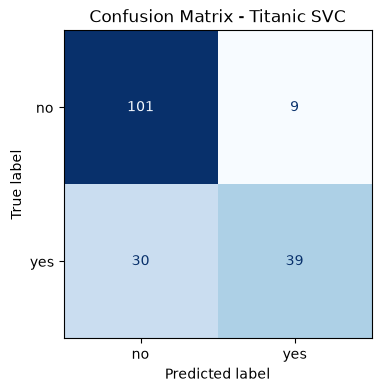

In [19]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title("Confusion Matrix - Titanic SVC")
plt.show()

ROC-AUC: 0.8137


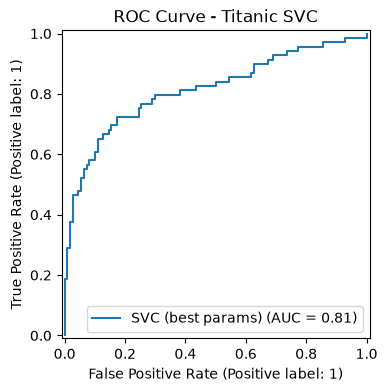

In [20]:
decision_scores = best_SVC_model.decision_function(X_test)
auc = roc_auc_score(y_test, decision_scores)
print(f"ROC-AUC: {auc:.4f}")

fig, ax = plt.subplots(figsize=(5, 4))
RocCurveDisplay.from_predictions(y_test, decision_scores, ax=ax, name="SVC (best params)")
ax.set_title("ROC Curve - Titanic SVC")
plt.show()

### A.9 Illustrative 2D Decision Boundary

The real Titanic model lives in a high-dimensional, one-hot-encoded feature space, so it can't be
drawn directly. To make the *shape* of an SVM boundary concrete, we fit a throw-away SVC on just two
scaled numeric features (`Age`, `Fare`) and plot its decision regions. This is purely illustrative —
it is **not** the production model from A.7.

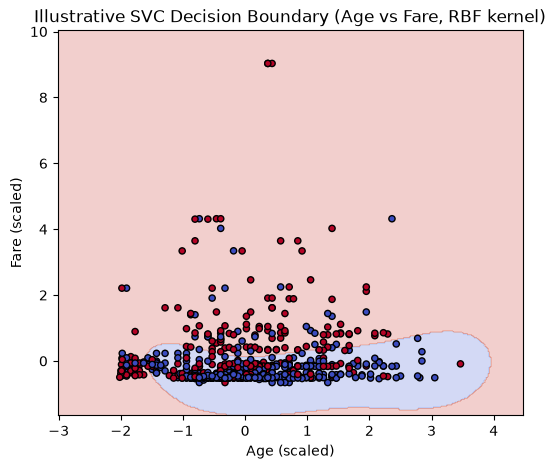

In [21]:
viz_df = df.dropna(subset=['Age', 'Fare', 'Survived']).copy()
X_viz = viz_df[['Age', 'Fare']].values
y_viz = LabelEncoder().fit_transform(viz_df['Survived'])

scaler_viz = StandardScaler()
X_viz_scaled = scaler_viz.fit_transform(X_viz)

svc_viz = SVC(kernel='rbf', C=1, gamma='scale')
svc_viz.fit(X_viz_scaled, y_viz)

xx, yy = np.meshgrid(
    np.linspace(X_viz_scaled[:, 0].min() - 1, X_viz_scaled[:, 0].max() + 1, 300),
    np.linspace(X_viz_scaled[:, 1].min() - 1, X_viz_scaled[:, 1].max() + 1, 300)
)
Z = svc_viz.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(6, 5))
ax.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
ax.scatter(X_viz_scaled[:, 0], X_viz_scaled[:, 1], c=y_viz, cmap='coolwarm', edgecolors='k', s=20)
ax.set_xlabel("Age (scaled)")
ax.set_ylabel("Fare (scaled)")
ax.set_title("Illustrative SVC Decision Boundary (Age vs Fare, RBF kernel)")
plt.show()

## Part B — Kernel Trick Demo: Linear vs Polynomial vs RBF

To make the **kernel trick** concrete, we generate one non-linear 2D dataset (`make_moons`) and fit
the *same* `SVC` with three different kernels. A `linear` kernel can only draw a straight line, so it
should perform worst on a curved boundary; `poly` and `rbf` can bend to follow the moon shapes.

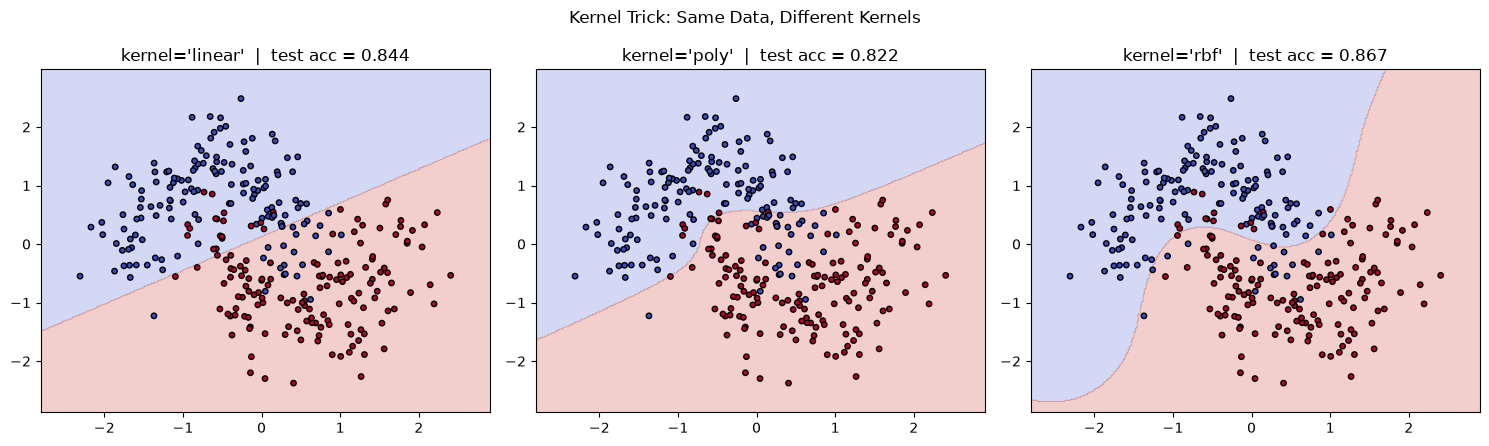

In [22]:
from sklearn.datasets import make_moons

X_moons, y_moons = make_moons(n_samples=300, noise=0.25, random_state=RANDOM_STATE)
X_moons = StandardScaler().fit_transform(X_moons)

Xm_train, Xm_test, ym_train, ym_test = train_test_split(
    X_moons, y_moons, test_size=0.3, random_state=RANDOM_STATE, stratify=y_moons
)

kernels = ['linear', 'poly', 'rbf']
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

xx, yy = np.meshgrid(
    np.linspace(X_moons[:, 0].min() - 0.5, X_moons[:, 0].max() + 0.5, 300),
    np.linspace(X_moons[:, 1].min() - 0.5, X_moons[:, 1].max() + 0.5, 300)
)

for ax, kernel in zip(axes, kernels):
    model = SVC(kernel=kernel, C=1, gamma='scale', degree=3)
    model.fit(Xm_train, ym_train)
    score = model.score(Xm_test, ym_test)

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
    ax.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='coolwarm', edgecolors='k', s=15)
    ax.set_title(f"kernel='{kernel}'  |  test acc = {score:.3f}")

plt.suptitle("Kernel Trick: Same Data, Different Kernels")
plt.tight_layout()
plt.show()

## Part C — Effect of `C` and `gamma` (Under-fitting vs Over-fitting)

Using the same moons dataset with an RBF kernel, we sweep a small grid of `C` (margin
strictness / penalty for misclassification) and `gamma` (how localized each point's influence is).

- **Small `C`** -> wider margin, tolerates more misclassification (can under-fit)
- **Large `C`** -> narrower margin, punishes misclassification heavily (can over-fit)
- **Small `gamma`** -> each point influences a wide region -> smoother, simpler boundary (can under-fit)
- **Large `gamma`** -> each point influences only its immediate neighborhood -> wiggly boundary that can
  wrap tightly around individual points (can over-fit)


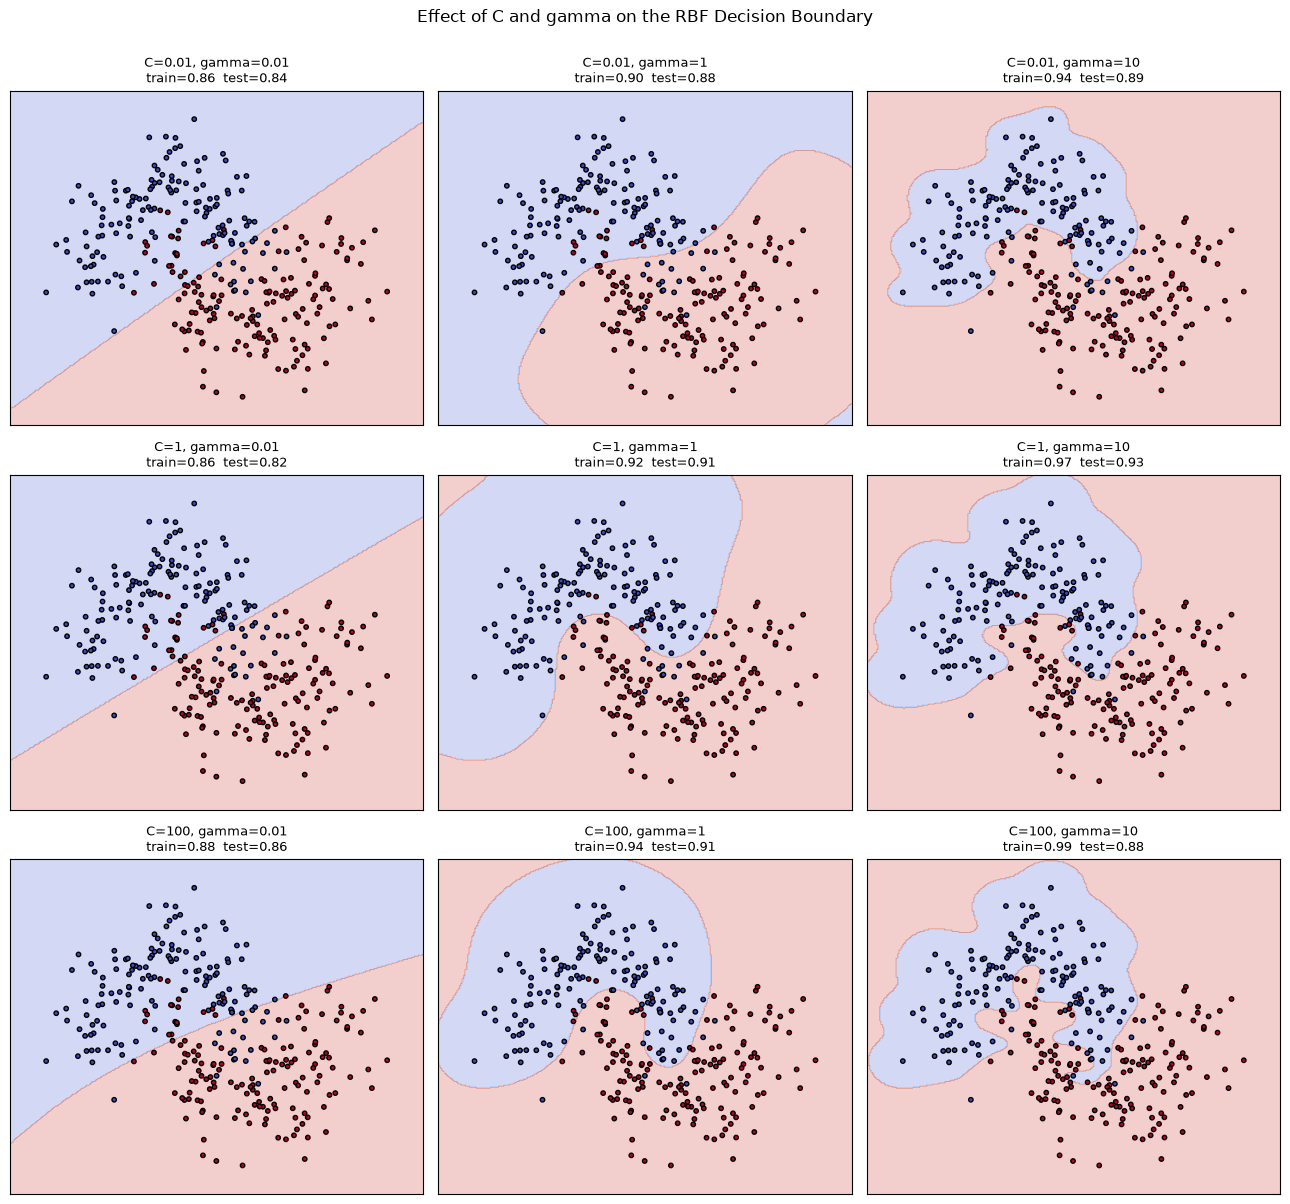

In [23]:
C_values = [0.01, 1, 100]
gamma_values = [0.01, 1, 10]

fig, axes = plt.subplots(len(C_values), len(gamma_values), figsize=(13, 12))

for i, C in enumerate(C_values):
    for j, gamma in enumerate(gamma_values):
        ax = axes[i, j]
        model = SVC(kernel='rbf', C=C, gamma=gamma)
        model.fit(Xm_train, ym_train)
        train_score = model.score(Xm_train, ym_train)
        test_score = model.score(Xm_test, ym_test)

        Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
        ax.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
        ax.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='coolwarm', edgecolors='k', s=10)
        ax.set_title(f"C={C}, gamma={gamma}\ntrain={train_score:.2f}  test={test_score:.2f}", fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])

plt.suptitle("Effect of C and gamma on the RBF Decision Boundary", y=1.0)
plt.tight_layout()
plt.show()

In [24]:
# Same sweep as a numeric table (easier to scan than the plot grid)
records = []
for C in C_values:
    for gamma in gamma_values:
        model = SVC(kernel='rbf', C=C, gamma=gamma)
        model.fit(Xm_train, ym_train)
        records.append({
            'C': C, 'gamma': gamma,
            'train_acc': model.score(Xm_train, ym_train),
            'test_acc': model.score(Xm_test, ym_test)
        })
pd.DataFrame(records)

,C,gamma,train_acc,test_acc
0,0.01,0.01,0.857143,0.844444
1,0.01,1.00,0.895238,0.877778
2,0.01,10.00,0.942857,0.888889
3,1.00,0.01,0.861905,0.822222
4,1.00,1.00,0.923810,0.911111
5,1.00,10.00,0.966667,0.933333
6,100.00,0.01,0.876190,0.855556
7,100.00,1.00,0.942857,0.911111
8,100.00,10.00,0.985714,0.877778


## Part D — Support Vector Regression (SVR)

SVR carries the *margin* idea over to regression: instead of separating classes with the widest
street, SVR fits a curve with an **epsilon-insensitive tube** around it. Points that fall inside the
tube (error `<= epsilon`) contribute **zero loss** — the model doesn't care about being "almost
right". Only points that stick out of the tube are penalized, and (as with SVC) only a subset of
points — the ones on or outside the tube boundary — end up mattering, i.e. the **support vectors**.

Loss (epsilon-insensitive):

```
L_eps(y, y_hat) = max(0, |y - y_hat| - epsilon)
```

Objective (soft-margin SVR, mirrors the SVC objective but with the epsilon-tube loss and two slack
variables — one for points above the tube, one for points below):

```
minimize   (1/2)||w||^2 + C * sum_i (xi_i + xi_i*)
subject to  y_i - (w.x_i + b)      <= epsilon + xi_i
            (w.x_i + b) - y_i      <= epsilon + xi_i*
            xi_i, xi_i* >= 0
```

See `README.md` for the full derivation and hand-worked numeric intuition.

### D.1 1D Toy Example — Visualizing the Epsilon Tube

We build a small non-linear 1D dataset (`y = sin(x)` plus noise) specifically because it makes the
epsilon-insensitive tube easy to see: the shaded band around the fitted curve is the region where the
model pays **no** penalty at all.

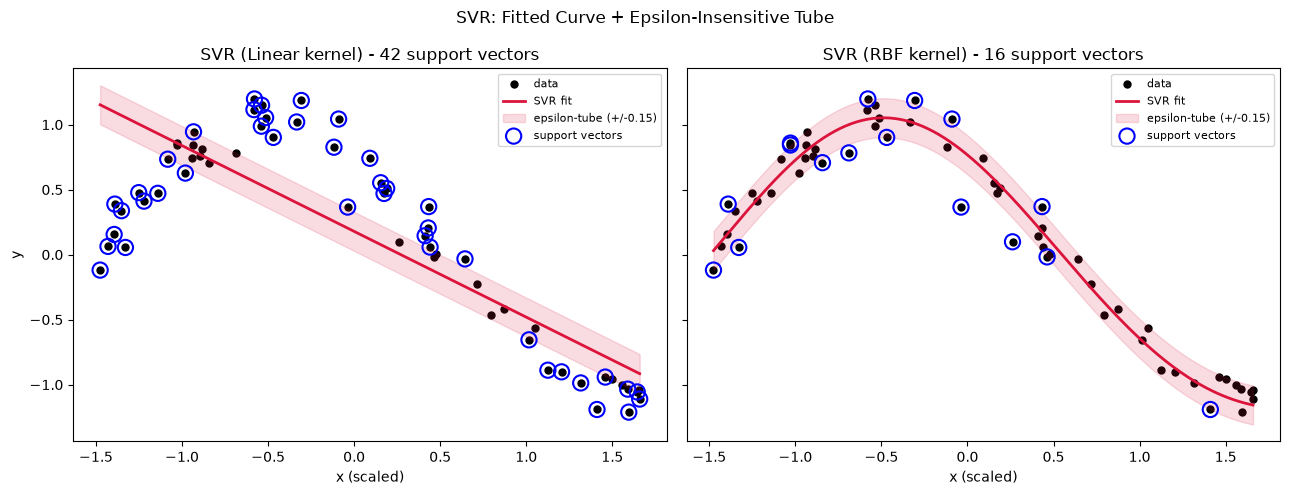

In [25]:
rng = np.random.RandomState(RANDOM_STATE)
X_toy = np.sort(5 * rng.rand(60, 1), axis=0)
y_toy = np.sin(X_toy).ravel() + 0.15 * rng.randn(60)

scaler_x_toy = StandardScaler()
X_toy_scaled = scaler_x_toy.fit_transform(X_toy)

EPSILON = 0.15

svr_lin_toy = SVR(kernel='linear', C=10, epsilon=EPSILON)
svr_rbf_toy = SVR(kernel='rbf', C=10, gamma=0.5, epsilon=EPSILON)

svr_lin_toy.fit(X_toy_scaled, y_toy)
svr_rbf_toy.fit(X_toy_scaled, y_toy)

X_plot = np.linspace(X_toy_scaled.min(), X_toy_scaled.max(), 300).reshape(-1, 1)
y_lin_pred = svr_lin_toy.predict(X_plot)
y_rbf_pred = svr_rbf_toy.predict(X_plot)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, y_pred, title, model in zip(
    axes, [y_lin_pred, y_rbf_pred], ["Linear kernel", "RBF kernel"], [svr_lin_toy, svr_rbf_toy]
):
    ax.scatter(X_toy_scaled, y_toy, color='black', s=25, label='data')
    ax.plot(X_plot, y_pred, color='crimson', lw=2, label='SVR fit')
    ax.fill_between(X_plot.ravel(), y_pred - EPSILON, y_pred + EPSILON,
                     color='crimson', alpha=0.15, label=f'epsilon-tube (+/-{EPSILON})')
    sv_idx = model.support_
    ax.scatter(X_toy_scaled[sv_idx], y_toy[sv_idx], facecolors='none',
               edgecolors='blue', s=120, linewidths=1.5, label='support vectors')
    ax.set_title(f"SVR ({title}) - {len(sv_idx)} support vectors")
    ax.set_xlabel("x (scaled)")
    ax.legend(fontsize=8)

axes[0].set_ylabel("y")
plt.suptitle("SVR: Fitted Curve + Epsilon-Insensitive Tube")
plt.tight_layout()
plt.show()

Notice that points **inside** the shaded tube are not circled as support vectors — they incur
zero loss and don't influence the fit. Only the points touching or outside the tube become support
vectors, exactly like only the closest points to the margin matter for SVC.

### D.2 Real Dataset — `load_diabetes`

Now a full, real regression workflow: load the diabetes dataset (442 patients, 10 baseline features,
target = disease progression score one year later), scale features (and the target, since SVR's
`epsilon` is defined on the target's raw scale — an unscaled target can make `epsilon` effectively
meaningless), split, fit linear vs RBF kernels, and compare with the standard regression metrics.

In [26]:
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()
X_diab, y_diab = diabetes.data, diabetes.target

Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    X_diab, y_diab, test_size=0.2, random_state=RANDOM_STATE
)

x_scaler = StandardScaler()
Xd_train_scaled = x_scaler.fit_transform(Xd_train)
Xd_test_scaled = x_scaler.transform(Xd_test)

# Scale the target too (SVR's epsilon tube width is in target units)
y_scaler = StandardScaler()
yd_train_scaled = y_scaler.fit_transform(yd_train.reshape(-1, 1)).ravel()

In [27]:
def evaluate_svr(model, X_test_scaled, y_test_true, y_scaler):
    y_pred_scaled = model.predict(X_test_scaled)
    y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

    mse = mean_squared_error(y_test_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_true, y_pred)
    r2 = r2_score(y_test_true, y_pred)
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2}, y_pred


svr_linear = SVR(kernel='linear', C=1.0, epsilon=0.1)
svr_rbf = SVR(kernel='rbf', C=1.0, gamma='scale', epsilon=0.1)

svr_linear.fit(Xd_train_scaled, yd_train_scaled)
svr_rbf.fit(Xd_train_scaled, yd_train_scaled)

metrics_linear, pred_linear = evaluate_svr(svr_linear, Xd_test_scaled, yd_test, y_scaler)
metrics_rbf, pred_rbf = evaluate_svr(svr_rbf, Xd_test_scaled, yd_test, y_scaler)

results = pd.DataFrame({'SVR (linear)': metrics_linear, 'SVR (rbf)': metrics_rbf}).T
results

,MSE,RMSE,MAE,R2
SVR (linear),2943.054241,54.249924,43.091361,0.444513
SVR (rbf),2526.617582,50.265471,38.924270,0.523113


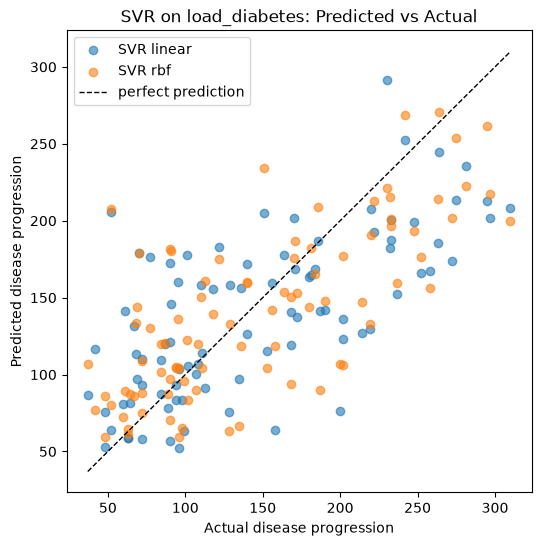

In [28]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(yd_test, pred_linear, alpha=0.6, label='SVR linear')
ax.scatter(yd_test, pred_rbf, alpha=0.6, label='SVR rbf')
lims = [min(yd_test.min(), pred_linear.min(), pred_rbf.min()),
        max(yd_test.max(), pred_linear.max(), pred_rbf.max())]
ax.plot(lims, lims, 'k--', lw=1, label='perfect prediction')
ax.set_xlabel("Actual disease progression")
ax.set_ylabel("Predicted disease progression")
ax.set_title("SVR on load_diabetes: Predicted vs Actual")
ax.legend()
plt.show()

### D.3 Quick `C` / `epsilon` sanity sweep (SVR)

Same idea as Part C, but for regression: a small grid over `C` and `epsilon` on the diabetes RBF
model, scored with R-squared on the held-out test set.

In [29]:
records = []
for C in [0.1, 1, 10]:
    for epsilon in [0.01, 0.1, 0.5]:
        model = SVR(kernel='rbf', C=C, gamma='scale', epsilon=epsilon)
        model.fit(Xd_train_scaled, yd_train_scaled)
        metrics, _ = evaluate_svr(model, Xd_test_scaled, yd_test, y_scaler)
        records.append({'C': C, 'epsilon': epsilon, 'R2': metrics['R2'], 'RMSE': metrics['RMSE']})

pd.DataFrame(records).sort_values('R2', ascending=False).reset_index(drop=True)

,C,epsilon,R2,RMSE
0,1.0,0.10,0.523113,50.265471
1,1.0,0.01,0.520078,50.425186
2,1.0,0.50,0.487855,52.090507
3,0.1,0.10,0.478677,52.555170
4,0.1,0.01,0.475339,52.723202
5,0.1,0.50,0.434859,54.719305
6,10.0,0.50,0.344730,58.921284
7,10.0,0.10,0.266670,62.332106
8,10.0,0.01,0.235918,63.625655


## Summary

- **Part A** showed the full SVC pipeline on a real, messy tabular dataset (Titanic) with proper
  preprocessing, `GridSearchCV`, and a complete metric suite.
- **Part B** made the **kernel trick** visible: same data, three kernels, three very different
  boundaries.
- **Part C** showed how `C` and `gamma` trade off under-fitting vs over-fitting.
- **Part D** did the same for regression: SVR's epsilon-tube intuition on a toy curve, then a full
  real-dataset regression with proper metrics.

For the theory behind every formula used here (margin derivation, hinge loss, hand-worked numeric
example, hyperparameter effects, pitfalls, and how SVM compares to logistic regression / trees / KNN),
see `README.md` in this folder.